# ASR Statistics Plots

This notebook loads per-model ASR results and compares models using:
- cpWER for faster-whisper and whisperx
- WER for parakeet and wav2vec2

Score selection per clip $i$ for model $m$:

$$
\text{score}_{i,m}=\begin{cases}
\text{cpWER}_{i,m}, & m\in\{\text{faster-whisper},\ \text{whisperx}\} \\
\text{WER}_{i,m}, & m\in\{\text{parakeet},\ \text{wav2vec2}\}
\end{cases}
$$

Condition mean score (for SNR/OVR plots):

$$
\overline{\text{score}}_{m,c}=\frac{1}{N_{m,c}}\sum_{i\in c}\text{score}_{i,m}
$$

Average inference time per item (not per batch):

$$
\text{time\_per\_item}_m=\frac{\sum_b \text{duration}_{m,b}}{\sum_b \text{items}_{m,b}}
$$

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "WER_Results_by_Model").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "WER_Results_by_Model"
MANIFEST_PATH = PROJECT_ROOT / "Output" / "manifest.csv"
TIMINGS_PATH = PROJECT_ROOT / "timings.json"
PLOTS_DIR = PROJECT_ROOT / "Output" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_METRIC = {
    "faster-whisper": "cpwer",
    "whisperx": "cpwer",
    "parakeet": "wer",
    "wav2vec2": "wer",
}

MODEL_ORDER = ["faster-whisper", "whisperx", "parakeet", "wav2vec2"]
MODEL_COLORS = {
    "faster-whisper": "#1f77b4",
    "whisperx": "#ff7f0e",
    "parakeet": "#2ca02c",
    "wav2vec2": "#d62728",
}

def metric_for_model(model_name: str) -> str:
    return MODEL_METRIC.get(model_name, "wer")

def selected_score(row: pd.Series) -> float:
    metric_name = metric_for_model(row["model"])
    value = row.get(metric_name)
    return value if pd.notna(value) else np.nan

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Plots dir: {PLOTS_DIR}")

Project root: /home/jamin/Year3Proj
Results dir: /home/jamin/Year3Proj/WER_Results_by_Model
Plots dir: /home/jamin/Year3Proj/Output/plots


In [12]:
def load_model_results(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    rows = []
    for result_path in sorted(results_dir.glob("*_wer_results.json")):
        with open(result_path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        model = payload.get("model", result_path.stem.replace("_wer_results", ""))
        for item in payload.get("results", []):
            metrics = item.get("metrics", {}) if item.get("status") == "success" else {}
            row = {
                "model": model,
                "clip_id": item.get("clip_id"),
                "status": item.get("status"),
                "metric_type": item.get("metric_type"),
                "wer": metrics.get("wer", np.nan),
                "cpwer": metrics.get("cpwer", np.nan),
                "score": np.nan,
            }
            row["score"] = selected_score(pd.Series(row))
            rows.append(row)
    return pd.DataFrame(rows)


def _format_snr_label(value) -> str:
    if pd.isna(value):
        return "clean"
    numeric = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric):
        return str(value)
    return f"{float(numeric):g}"


def load_manifest(manifest_path: Path = MANIFEST_PATH) -> pd.DataFrame:
    manifest = pd.read_csv(manifest_path)
    keep_cols = [col for col in ["clip_id", "overlap_ratio_target", "overlap_ratio_actual", "snr_db", "noise_type"] if col in manifest.columns]
    manifest = manifest[keep_cols].copy()
    if "snr_db" in manifest.columns:
        manifest["snr_label"] = manifest["snr_db"].apply(_format_snr_label)
    if "overlap_ratio_target" in manifest.columns:
        manifest["ovr_label"] = manifest["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")
    return manifest


def _count_items_from_timing_key(key: str, prefix: str) -> int:
    suffix = key.replace(f"transcribe_{prefix}_", "", 1)
    # Keys end with an extra trailing separator, so drop empty chunks.
    parts = [chunk for chunk in suffix.split("_-") if chunk]
    return len(parts)


def load_timings(timings_path: Path = TIMINGS_PATH) -> pd.DataFrame:
    with open(timings_path, "r", encoding="utf-8") as handle:
        timings = json.load(handle)
    rows = []
    model_prefixes = {
        "faster-whisper": "faster_whisper",
        "wav2vec2": "wav2vec2",
        "parakeet": "parakeet",
        "whisperx": "whisperx",
    }
    for key, duration in timings.items():
        for model_name, prefix in model_prefixes.items():
            if key.startswith(f"transcribe_{prefix}_"):
                rows.append(
                    {
                        "model": model_name,
                        "duration_sec": float(duration),
                        "item_count": _count_items_from_timing_key(key, prefix),
                        "batch_key": key,
                    }
                )
                break
    return pd.DataFrame(rows)


results_df = load_model_results()
manifest_df = load_manifest()
timings_df = load_timings()

results_df = results_df.merge(manifest_df, on="clip_id", how="left")
results_df["selected_metric_name"] = results_df["model"].map(metric_for_model)
results_df["selected_score"] = results_df.apply(selected_score, axis=1)

successful_df = results_df[results_df["status"] == "success"].copy()
successful_df = successful_df[pd.notna(successful_df["selected_score"])]

summary_df = (
    successful_df.groupby("model")
    .agg(
        clips=("clip_id", "count"),
        mean_score=("selected_score", "mean"),
        median_score=("selected_score", "median"),
    )
    .reset_index()
)

print(f"Loaded {len(results_df)} clip results across {results_df['model'].nunique()} models")
print(summary_df)

Loaded 14880 clip results across 4 models
            model  clips  mean_score  median_score
0  faster-whisper    610    0.761549      0.772346
1        parakeet    610    0.544461      0.565539
2        wav2vec2    610    0.252869      0.214550
3        whisperx    610    0.731198      0.735577


In [3]:
def model_palette(model_names):
    return {model: MODEL_COLORS.get(model, "#333333") for model in model_names}


def plot_metric_vs_condition(data: pd.DataFrame, condition_col: str, title: str, ylabel: str, filename: str) -> None:
    plot_data = data.dropna(subset=[condition_col, "selected_score"]).copy()
    plot_data[condition_col] = pd.to_numeric(plot_data[condition_col], errors="coerce")
    plot_data = plot_data.dropna(subset=[condition_col])
    plot_data = plot_data.sort_values(condition_col)

    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=plot_data,
        x=condition_col,
        y="selected_score",
        hue="model",
        hue_order=MODEL_ORDER,
        palette=model_palette(MODEL_ORDER),
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        linewidth=2.2,
    )
    plt.title(title)
    plt.xlabel(condition_col.replace("_", " ").upper())
    plt.ylabel(ylabel)
    plt.legend(title="Model", frameon=True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=200)
    plt.show()


def add_reference_line(ax):
    low, high = ax.get_xlim()
    ax.plot([low, high], [low, high], linestyle="--", color="#555555", linewidth=1)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)


print("Plot helpers ready")

Plot helpers ready


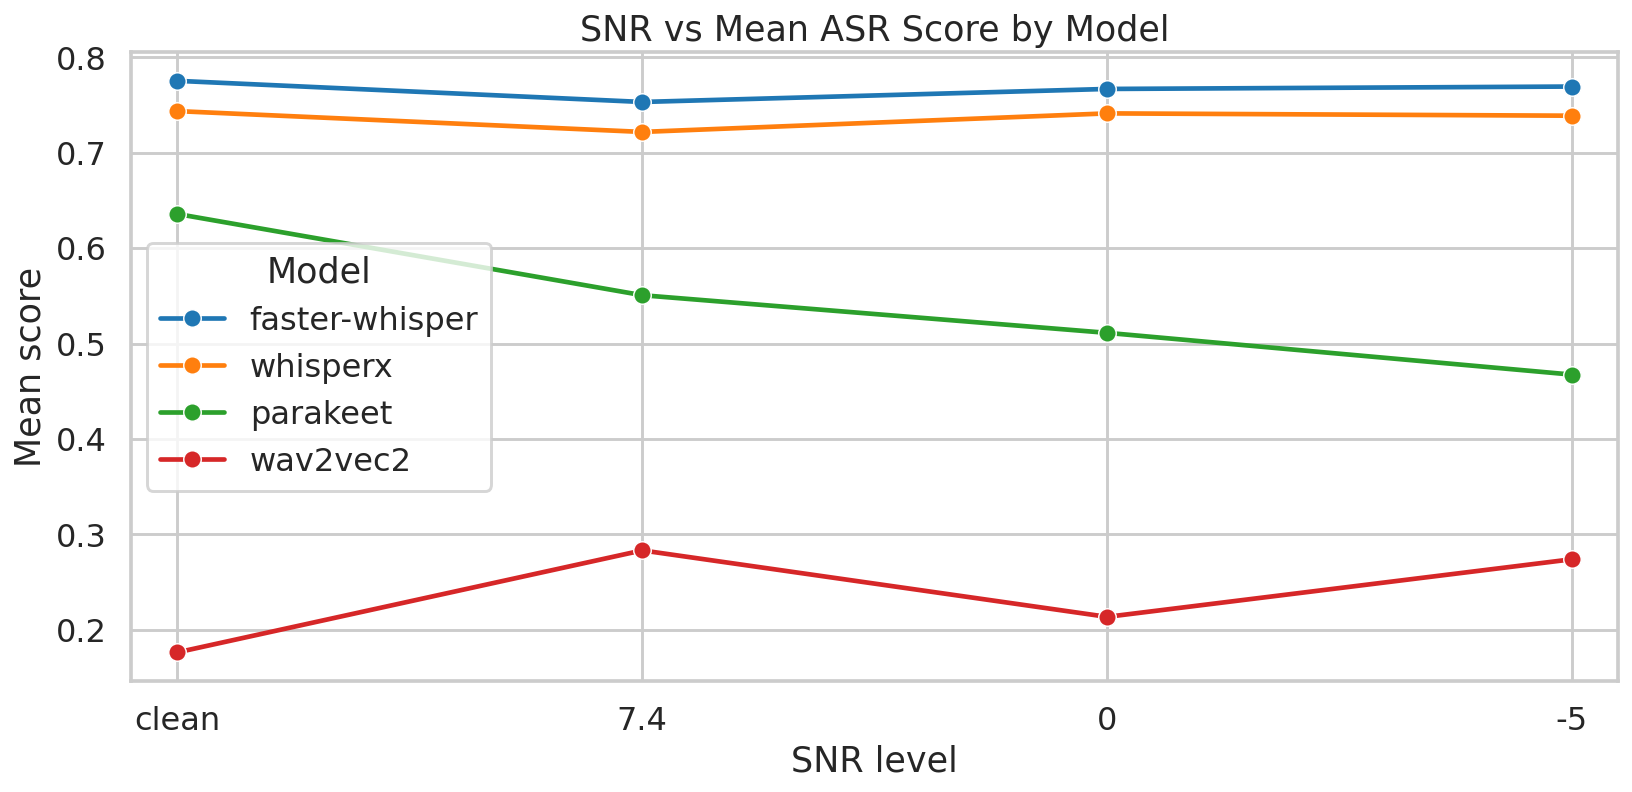

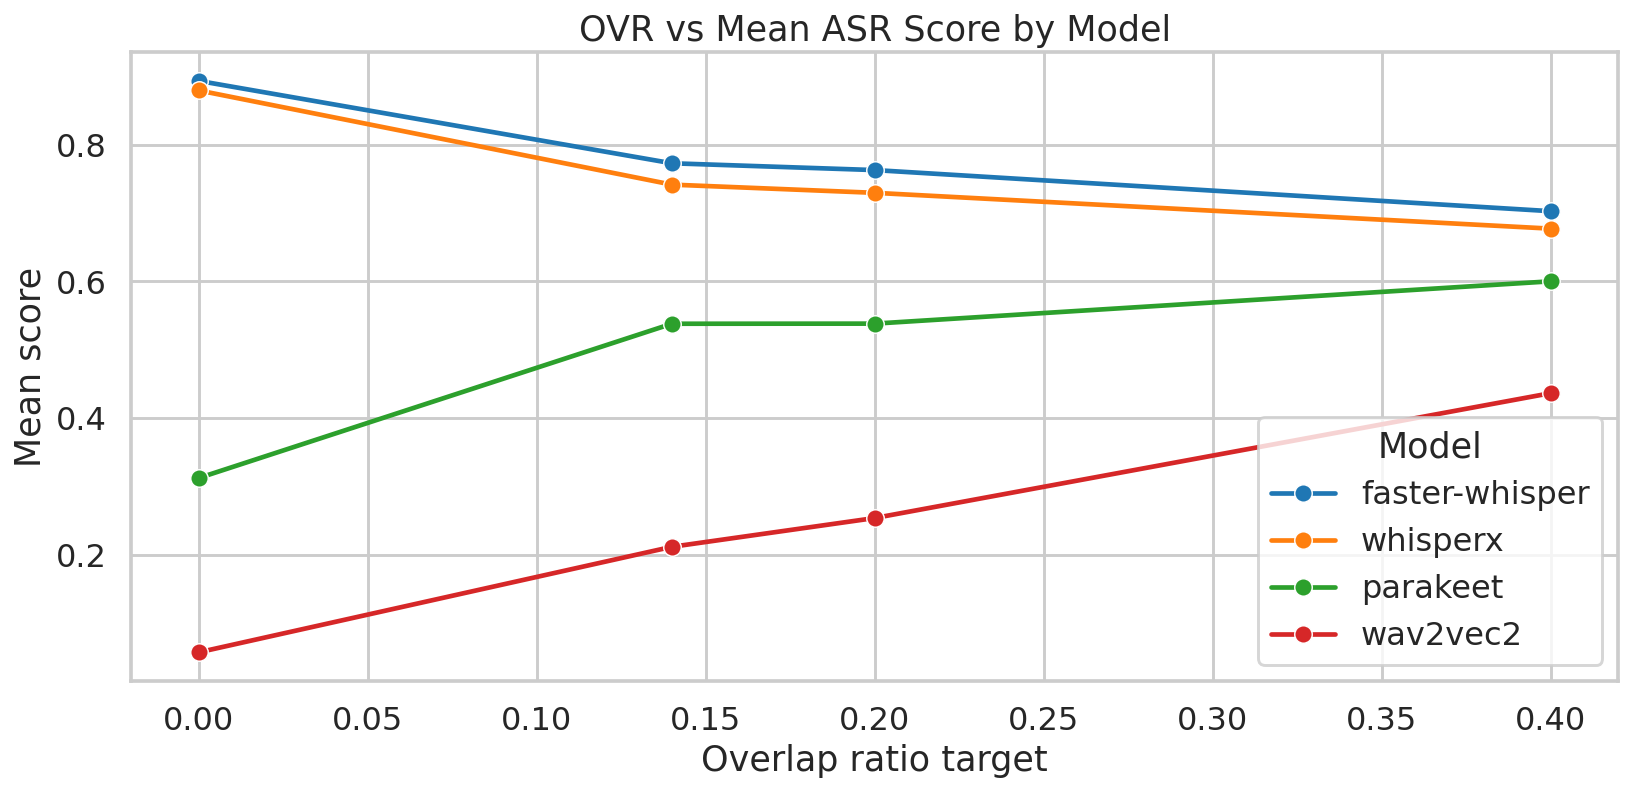

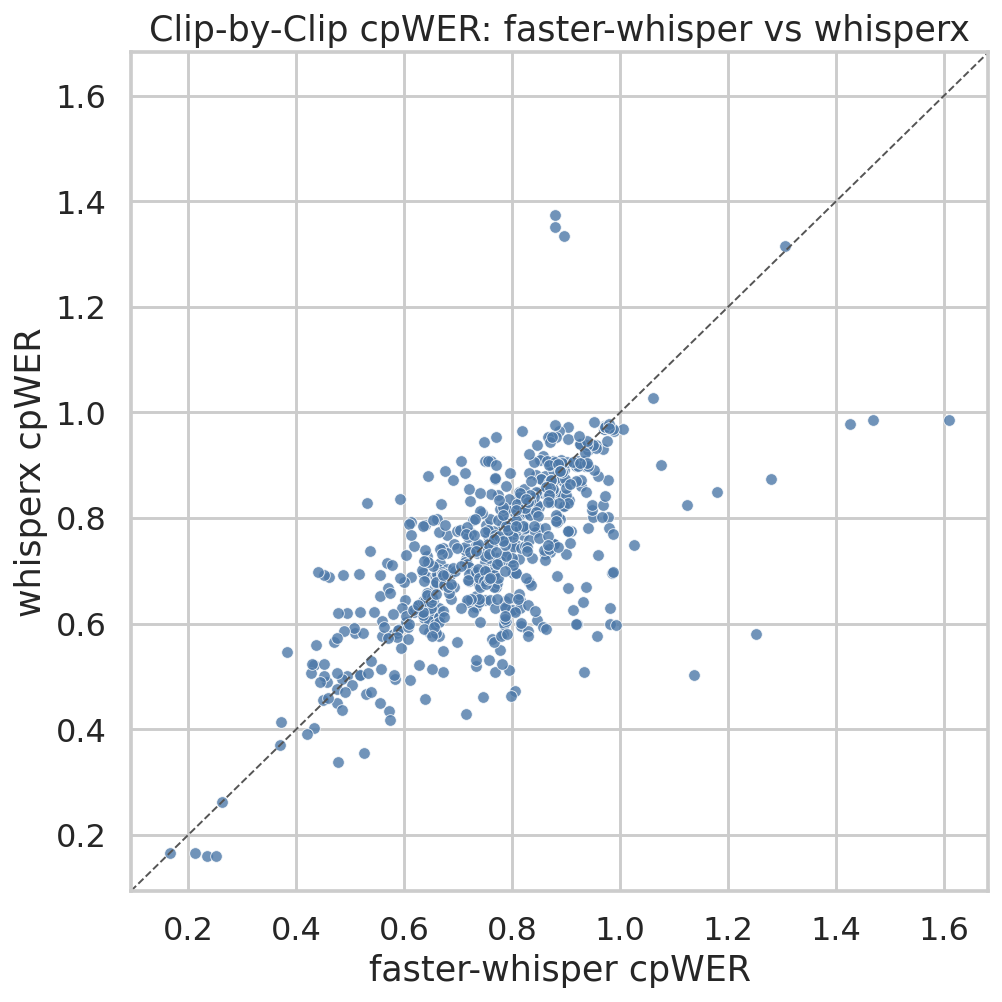

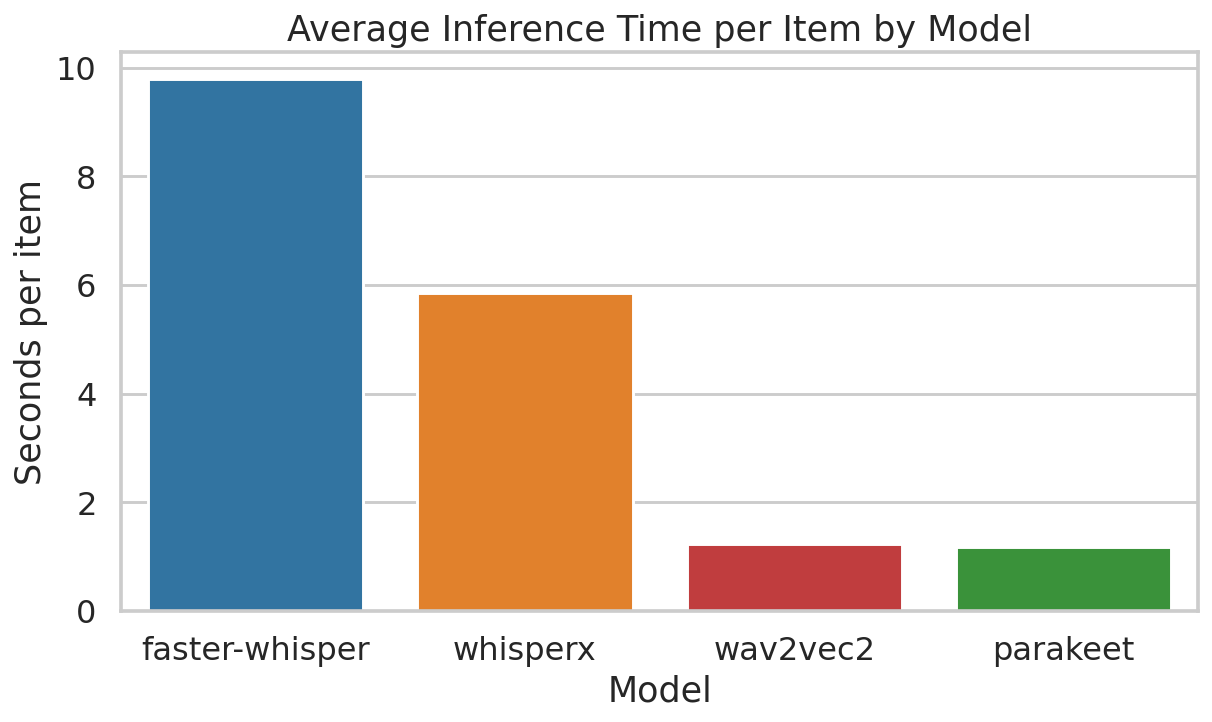

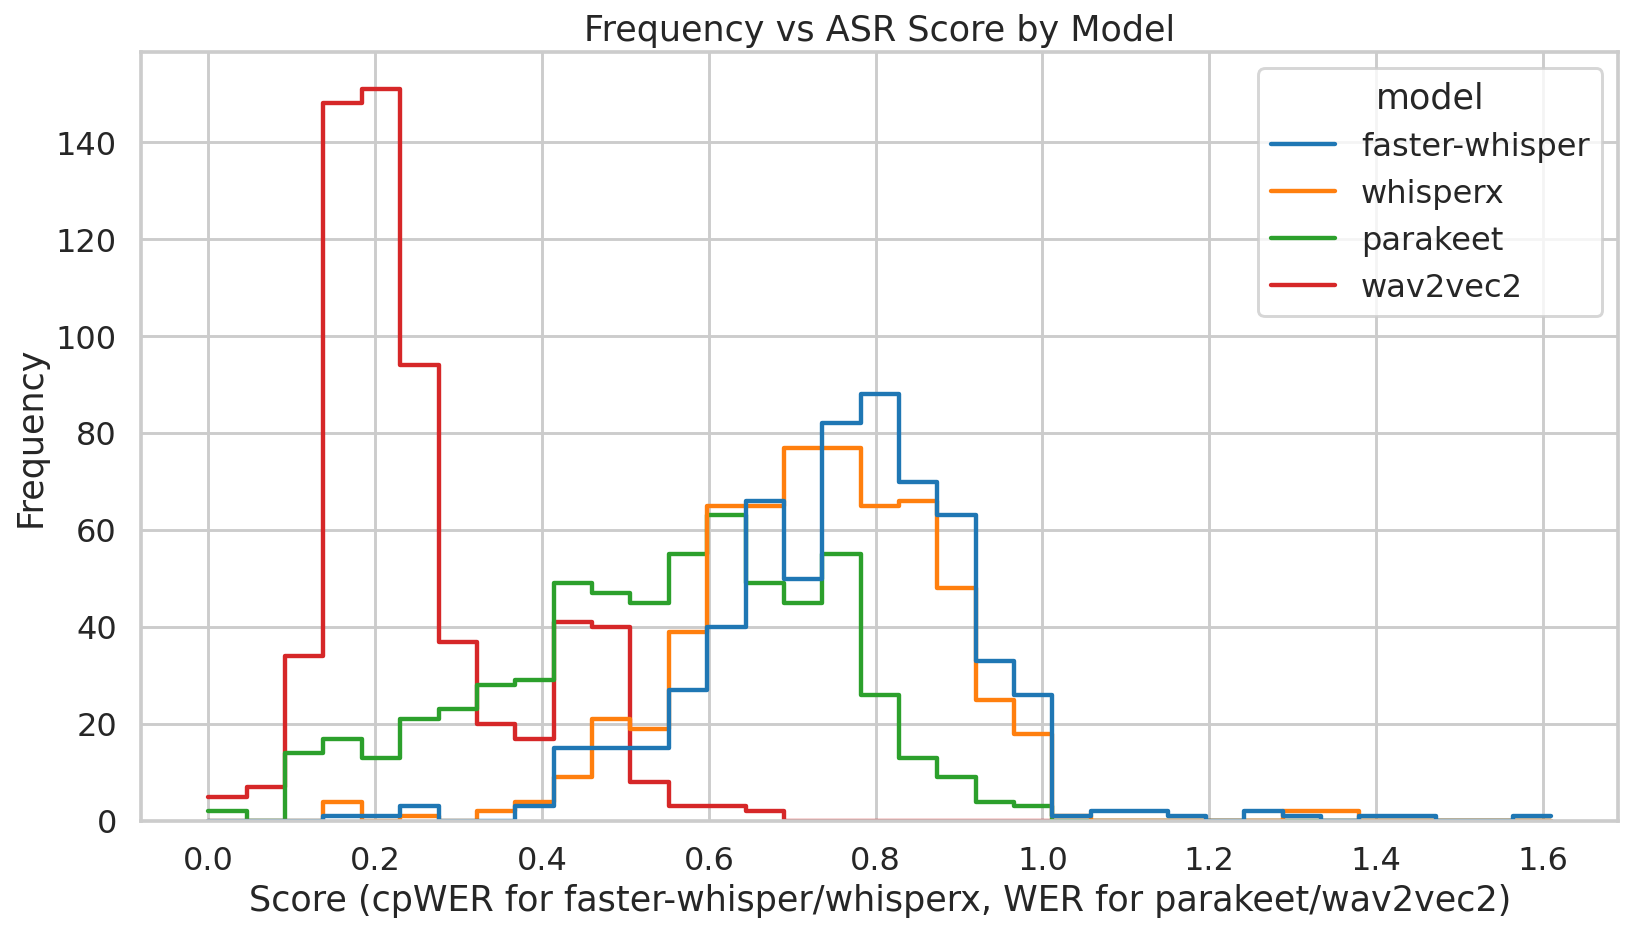

Saved plots to:
- /home/jamin/Year3Proj/Output/plots/snr_vs_mean_score_by_model.png
- /home/jamin/Year3Proj/Output/plots/ovr_vs_mean_score_by_model.png
- /home/jamin/Year3Proj/Output/plots/clip_by_clip_faster_whisper_vs_whisperx_cpwer.png
- /home/jamin/Year3Proj/Output/plots/average_timing_per_item_by_model.png
- /home/jamin/Year3Proj/Output/plots/frequency_vs_score_by_model.png


In [13]:
# SNR vs mean score with explicit order: clean, 7.4, 0, -5.
snr_order = ["clean", "7.4", "0", "-5"]
snr_pos = {label: idx for idx, label in enumerate(snr_order)}

snr_summary = (
    successful_df.dropna(subset=["snr_label", "selected_score"])
.copy()
)
snr_summary["snr_label"] = snr_summary["snr_label"].astype(str)
snr_summary = snr_summary[snr_summary["snr_label"].isin(snr_order)]
snr_summary = (
    snr_summary.groupby(["model", "snr_label"], as_index=False)["selected_score"]
    .mean()
)
snr_summary["snr_pos"] = snr_summary["snr_label"].map(snr_pos)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=snr_summary,
    x="snr_pos",
    y="selected_score",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
)
plt.xticks([0, 1, 2, 3], snr_order)
plt.xlim(-0.1, 3.1)
plt.title("SNR vs Mean ASR Score by Model")
plt.xlabel("SNR level")
plt.ylabel("Mean score")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "snr_vs_mean_score_by_model.png", dpi=200)
plt.show()

# OVR vs mean score for each model.
ovr_summary = (
    successful_df.dropna(subset=["overlap_ratio_target", "selected_score"])
.groupby(["model", "overlap_ratio_target"], as_index=False)["selected_score"]
    .mean()
    .sort_values(["model", "overlap_ratio_target"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ovr_summary,
    x="overlap_ratio_target",
    y="selected_score",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
)
plt.title("OVR vs Mean ASR Score by Model")
plt.xlabel("Overlap ratio target")
plt.ylabel("Mean score")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ovr_vs_mean_score_by_model.png", dpi=200)
plt.show()

# Clip-by-clip comparison between faster-whisper and whisperx using cpWER.
fw_whisperx = (
    results_df.loc[results_df["model"].isin(["faster-whisper", "whisperx"]) & (results_df["status"] == "success"),
                  ["clip_id", "model", "selected_score"]]
    .dropna()
    .pivot(index="clip_id", columns="model", values="selected_score")
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7.5, 7.5))
ax = sns.scatterplot(
    data=fw_whisperx,
    x="faster-whisper",
    y="whisperx",
    s=36,
    alpha=0.8,
    color="#4c78a8",
)
add_reference_line(ax)
plt.title("Clip-by-Clip cpWER: faster-whisper vs whisperx")
plt.xlabel("faster-whisper cpWER")
plt.ylabel("whisperx cpWER")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "clip_by_clip_faster_whisper_vs_whisperx_cpwer.png", dpi=200)
plt.show()

# Average inference time per item: total duration / total number of items.
timing_summary = (
    timings_df.groupby("model", as_index=False)
    .agg(total_duration_sec=("duration_sec", "sum"), total_items=("item_count", "sum"))
)
timing_summary["sec_per_item"] = timing_summary["total_duration_sec"] / timing_summary["total_items"]
timing_summary = timing_summary.sort_values("sec_per_item", ascending=False)

plt.figure(figsize=(9, 5.5))
sns.barplot(
    data=timing_summary,
    x="model",
    y="sec_per_item",
    order=timing_summary["model"],
    hue="model",
    hue_order=timing_summary["model"],
    palette=model_palette(timing_summary["model"]),
    legend=False,
)
plt.title("Average Inference Time per Item by Model")
plt.xlabel("Model")
plt.ylabel("Seconds per item")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "average_timing_per_item_by_model.png", dpi=200)
plt.show()

# Frequency vs score distribution for each model.
plt.figure(figsize=(12, 7))
sns.histplot(
    data=successful_df,
    x="selected_score",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    bins=35,
    stat="count",
    common_norm=False,
    element="step",
    fill=False,
)
plt.title("Frequency vs ASR Score by Model")
plt.xlabel("Score (cpWER for faster-whisper/whisperx, WER for parakeet/wav2vec2)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "frequency_vs_score_by_model.png", dpi=200)
plt.show()

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_score_by_model.png",
    "ovr_vs_mean_score_by_model.png",
    "clip_by_clip_faster_whisper_vs_whisperx_cpwer.png",
    "average_timing_per_item_by_model.png",
    "frequency_vs_score_by_model.png",
]:
    print(f"- {PLOTS_DIR / plot_name}")